In [1]:
import numpy as np
import pandas as pd
import glob
from sklearn.discriminant_analysis import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import random
from collections import defaultdict
from myUtils import *
import os
from pathlib import Path
import pickle
from matplotlib.patches import Circle


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# ----------------------------------
# Read filenames and divide them
# ----------------------------------
all_files = glob.glob("DCMotorUpAndDownStepDatasets/*.csv")

step_files   = [f for f in all_files]
train_val_files = step_files[10:]
test_files = step_files[:]

def split_category(file_list):
    train = file_list[:15]
    val   = file_list[15:]
    return train, val

train_files, val_files = split_category(train_val_files)

In [4]:
plt.rcParams.update({
    "font.size": 24,
    "axes.titlesize": 24,
    "axes.labelsize": 24,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
    "legend.fontsize": 24
})

In [22]:
# ----------------------------------
# Model
# ----------------------------------
class CustomOrderNetwork(nn.Module):
    def __init__(self, order):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1+order, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

In [23]:
def extract_transitions(file, window_size=100):
    data = pd.read_csv(file).values

    rising_segments = []
    falling_segments = []

    setpoint = data[:, 0]

    diff = np.diff(setpoint)
    
    rising_edges = list(np.where(diff == 1)[0] + 1)
    falling_edges = list(np.where(diff == -1)[0] + 1)

    if setpoint[0] == 1:
        rising_edges.insert(0, 0)

    for i in rising_edges:
        if i + window_size <= len(data):
            segment = data[i:i+window_size]
            rising_segments.append({
                "start_idx": i,
                "segment": segment
            })

    for i in falling_edges:
        if i + window_size <= len(data):
            segment = data[i:i+window_size]
            falling_segments.append({
                "start_idx": i,
                "segment": segment
            })

    return rising_segments, falling_segments

In [24]:
order = 2
num_runs = 30
all_rising_segments = []
all_falling_segments = []

for file_idx, file in enumerate(step_files):
    rising, falling = extract_transitions(file)
    for item in rising:
        item["file_idx"] = file_idx
        all_rising_segments.append(item)
    for item in falling:
        item["file_idx"] = file_idx
        all_falling_segments.append(item)

rising_vectors = []
falling_vectors = []
run_seeds = [0, 3, 4, 5, 6, 7, 8, 9, 12, 14, 15, 18, 19, 22, 23, 26, 29, 30, 32, 34, 38, 41, 43, 44, 45, 47, 48, 49, 53, 55]
#for run in range(num_runs):
for run in run_seeds:
    print(f"Run number {run}...")
    seed = 1000 + run
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    model = CustomOrderNetwork(2)
    model.load_state_dict(torch.load(f"DCmodelRunNumber{run}.pth"))
    model.to("cuda")

    grads_all = []

    for item in all_rising_segments:
        segment = item["segment"]
        grads = get_gradients_from_segment_test(model, segment, order)
        grads_vector = aggregate_y_gradients(grads, 2)
        grads_all.append(grads_vector)

    mean_grad = np.mean(np.array(grads_all), axis=0)
    rising_vectors.append(mean_grad)

    grads_all = []

    for item in all_falling_segments:
        segment = item["segment"]
        grads = get_gradients_from_segment_test(model, segment, order)
        grads_vector = aggregate_y_gradients(grads, 2)
        grads_all.append(grads_vector)

    mean_grad = np.mean(np.array(grads_all), axis=0)
    falling_vectors.append(mean_grad)

final_rising_grad = np.mean(np.array(rising_vectors), axis=0)
final_rising_grad = torch.tensor(final_rising_grad, device=device, dtype=torch.float32)
rising_norm = torch.max(torch.abs(final_rising_grad)) + 1e-8

final_falling_grad = np.mean(np.array(falling_vectors), axis=0)
final_falling_grad = torch.tensor(final_falling_grad, device=device, dtype=torch.float32)
falling_norm = torch.max(torch.abs(final_falling_grad)) + 1e-8

Run number 0...
Run number 3...
Run number 4...
Run number 5...
Run number 6...
Run number 7...
Run number 8...
Run number 9...
Run number 12...
Run number 14...
Run number 15...
Run number 18...
Run number 19...
Run number 22...
Run number 23...
Run number 26...
Run number 29...
Run number 30...
Run number 32...
Run number 34...
Run number 38...
Run number 41...
Run number 43...
Run number 44...
Run number 45...
Run number 47...
Run number 48...
Run number 49...
Run number 53...
Run number 55...


In [6]:
epsilons = [0.05, 0.1, 0.15, 0.2]
top_percentages = [25, 50, 75, 100]

In [26]:
all_charting_rising_deltas = {}
all_charting_falling_deltas = {}
all_gaussian_noises = {}

for top_percent in top_percentages:

    all_charting_rising_deltas[top_percent] = []
    all_charting_falling_deltas[top_percent] = []
    all_gaussian_noises[top_percent] = []
    noises = {}

    for epsilon in epsilons:

        rising_delta = epsilon * final_rising_grad / rising_norm
        rising_delta = torch.cat([rising_delta, torch.tensor([0.0], device=device)])

        falling_delta = epsilon * final_falling_grad / falling_norm
        falling_delta = torch.cat([falling_delta, torch.tensor([0.0], device=device)])
        
        def keep_top_percentage(delta, percentage):
            k = int(len(delta) * (percentage / 100))
            if k == len(delta):
                return delta
            values, indices = torch.topk(torch.abs(delta), k)
            mask = torch.zeros_like(delta)
            mask[indices] = 1

            return delta * mask

        rising_delta = keep_top_percentage(rising_delta, top_percent)
        falling_delta = keep_top_percentage(falling_delta, top_percent)

        rising_delta_np = rising_delta.detach().cpu().numpy()
        falling_delta_np = falling_delta.detach().cpu().numpy()

        all_charting_rising_deltas[top_percent].append(rising_delta_np)
        all_charting_falling_deltas[top_percent].append(falling_delta_np)

        rising_rms = np.sqrt(np.mean(rising_delta_np**2))
        falling_rms = np.sqrt(np.mean(falling_delta_np**2))
        combined_delta = np.concatenate([rising_delta_np, falling_delta_np])
        combined_rms = np.sqrt(np.mean(combined_delta**2))

        noise = torch.randn(100, device=device)
        noise_rms = torch.sqrt(torch.mean(noise**2))
        scaled_noise = noise * (combined_rms / noise_rms.item())
        scaled_noise_np = scaled_noise.detach().cpu().numpy()
        all_gaussian_noises[top_percent].append(scaled_noise_np)
        gaussian_rms = np.sqrt(np.mean(scaled_noise_np**2))

        print(
            f"TOP {top_percent}% | "
            f"eps={epsilon:.2f} | "
            f"rising RMS={rising_rms:.6f} | "
            f"falling RMS={falling_rms:.6f} | "
            f"combined RMS={combined_rms:.6f} | "
            f"gaussian RMS={gaussian_rms:.6f}"
        )

        noises[epsilon] = {
            "rising_noise": rising_delta_np.copy(),
            "falling_noise": falling_delta_np.copy(),
            "gaussian_noise": scaled_noise_np.copy(),
            "rising_rms": float(rising_rms),
            "falling_rms": float(falling_rms),
            "combined_rms": float(combined_rms),
            "gaussian_rms": float(gaussian_rms),
            "top_percentage": top_percent
        }

        calculated_modified_dfs = []
        gaussian_modified_dfs = []

        for filename in step_files:
            df = pd.read_csv(filename)
            calculated_modified_dfs.append(df.copy())
            gaussian_modified_dfs.append(df.copy())


        for item in all_rising_segments:
            file_idx = item["file_idx"]
            start_idx = item["start_idx"]
            segment = item["segment"]

            end_idx = start_idx + 100
            original = segment[:, 2]

            calculated_modified_dfs[file_idx].iloc[start_idx:end_idx, 2] = original + rising_delta_np
            gaussian_modified_dfs[file_idx].iloc[start_idx:end_idx, 2] = original + scaled_noise_np


        for item in all_falling_segments:
            file_idx = item["file_idx"]
            start_idx = item["start_idx"]
            segment = item["segment"]

            end_idx = start_idx + 100
            original = segment[:, 2]

            calculated_modified_dfs[file_idx].iloc[start_idx:end_idx, 2] = original + falling_delta_np
            gaussian_modified_dfs[file_idx].iloc[start_idx:end_idx, 2] = original + scaled_noise_np

        folder_path = Path(f"adversarialTop{top_percent}PercentDCMotorUpAndDownStepDatasets_{epsilon}")
        folder_path.mkdir(parents=True, exist_ok=True)

        for i, filename in enumerate(step_files):
            new_filename = os.path.join(folder_path, f"adversarial_top{top_percent}_calculated_DC_sum_test_{os.path.basename(filename)}")
            calculated_modified_dfs[i].to_csv(new_filename, index=False)

            new_filename = os.path.join(folder_path, f"adversarial_top{top_percent}_gaussian_DC_sum_test_{os.path.basename(filename)}")
            gaussian_modified_dfs[i].to_csv(new_filename, index=False)

    with open(f"protocol_1_adversarial_noises_top{top_percent}_DC_sum_test.pkl", "wb") as f:
        pickle.dump(noises, f)

TOP 25% | eps=0.05 | rising RMS=0.006678 | falling RMS=0.008275 | combined RMS=0.007519 | gaussian RMS=0.007519
TOP 25% | eps=0.10 | rising RMS=0.013357 | falling RMS=0.016550 | combined RMS=0.015038 | gaussian RMS=0.015038
TOP 25% | eps=0.15 | rising RMS=0.020035 | falling RMS=0.024825 | combined RMS=0.022558 | gaussian RMS=0.022558
TOP 25% | eps=0.20 | rising RMS=0.026713 | falling RMS=0.033100 | combined RMS=0.030077 | gaussian RMS=0.030077
TOP 50% | eps=0.05 | rising RMS=0.006716 | falling RMS=0.008374 | combined RMS=0.007590 | gaussian RMS=0.007590
TOP 50% | eps=0.10 | rising RMS=0.013432 | falling RMS=0.016747 | combined RMS=0.015180 | gaussian RMS=0.015180
TOP 50% | eps=0.15 | rising RMS=0.020149 | falling RMS=0.025121 | combined RMS=0.022771 | gaussian RMS=0.022771
TOP 50% | eps=0.20 | rising RMS=0.026865 | falling RMS=0.033494 | combined RMS=0.030361 | gaussian RMS=0.030361
TOP 75% | eps=0.05 | rising RMS=0.006731 | falling RMS=0.008419 | combined RMS=0.007622 | gaussian RMS=0

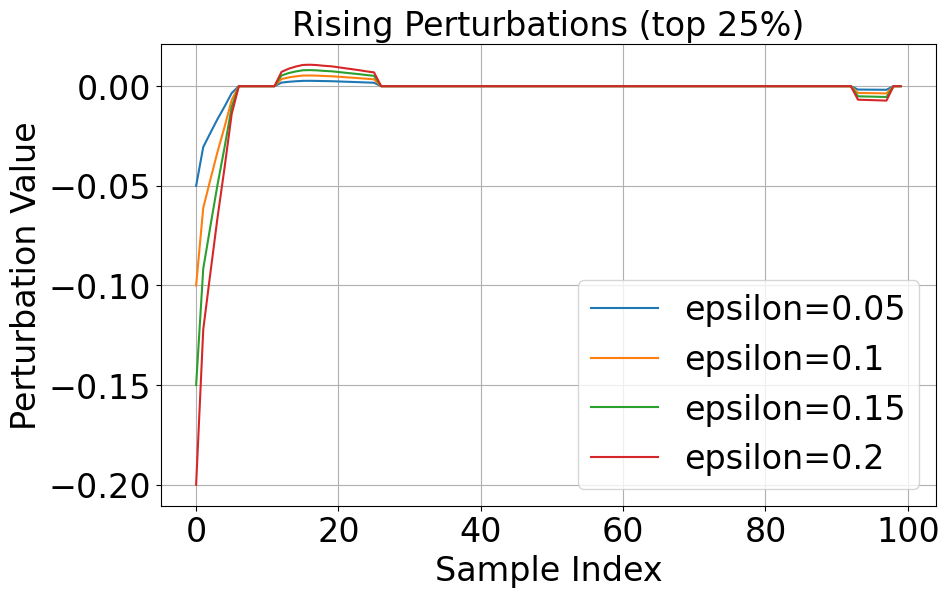

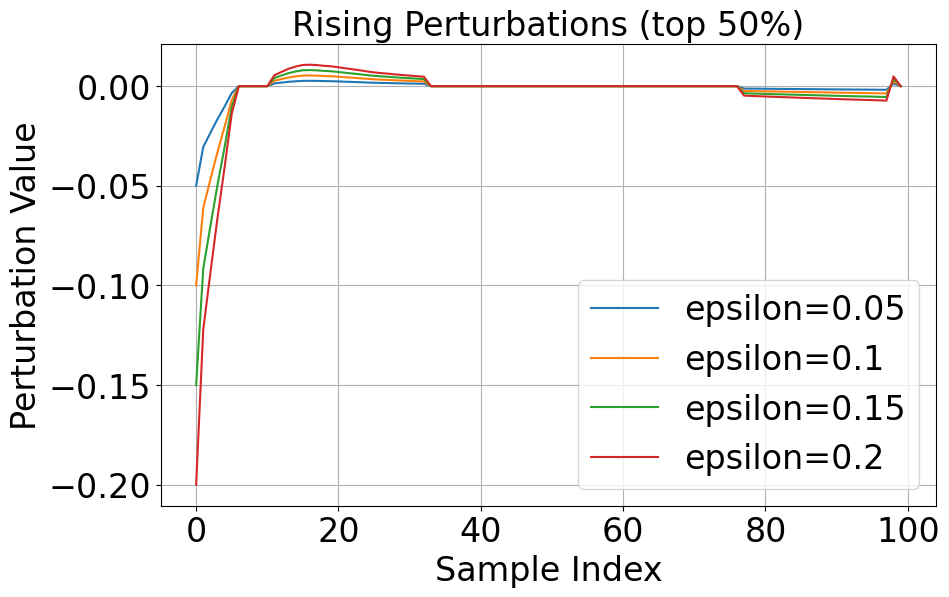

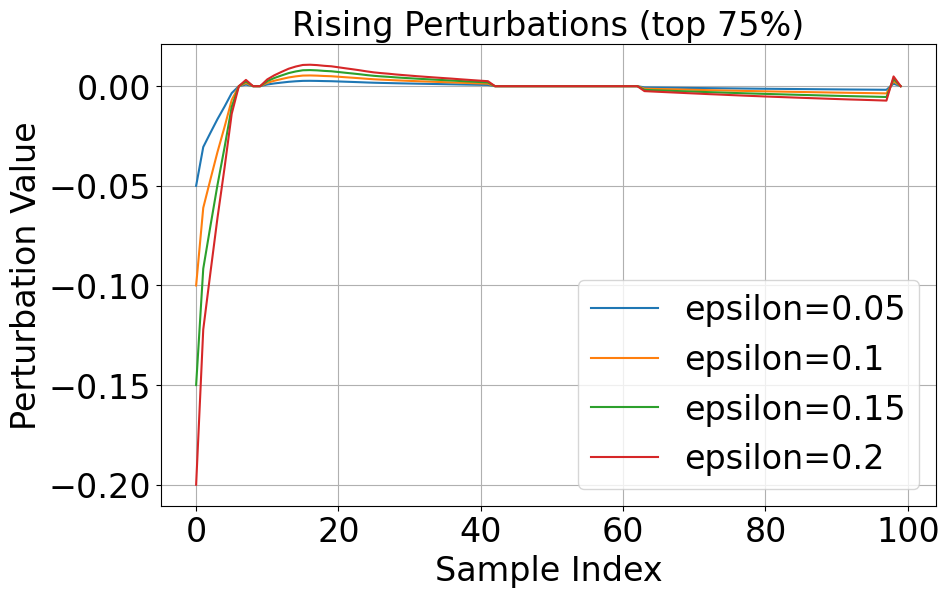

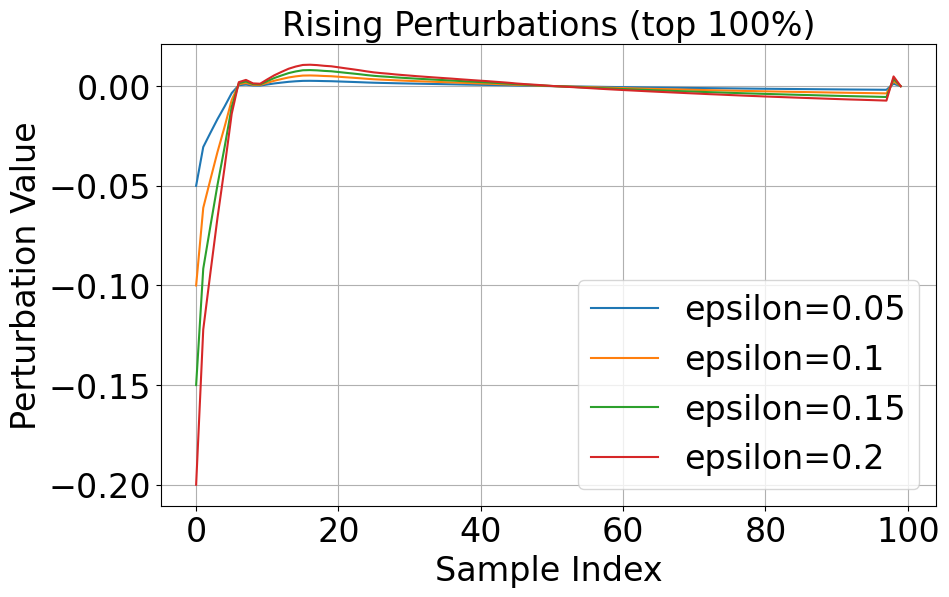

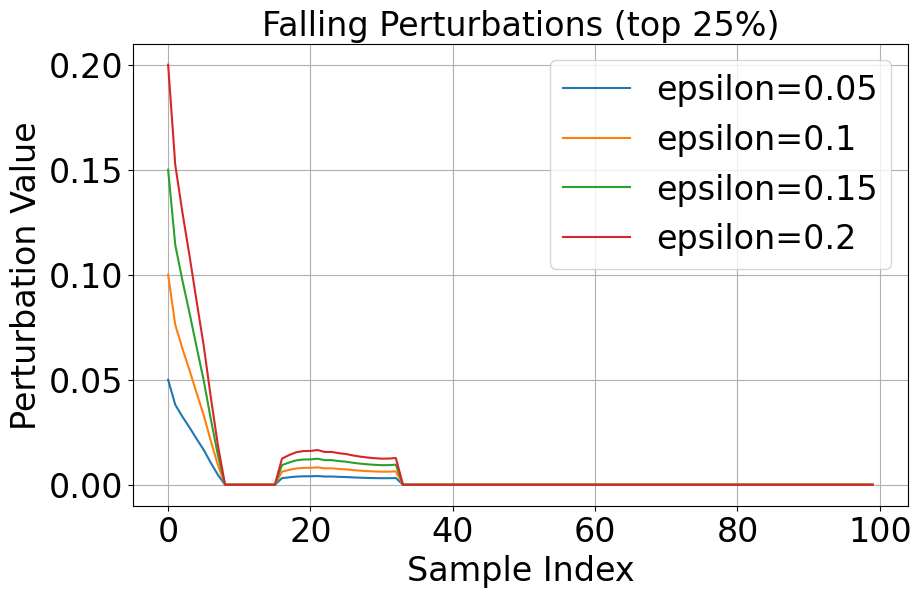

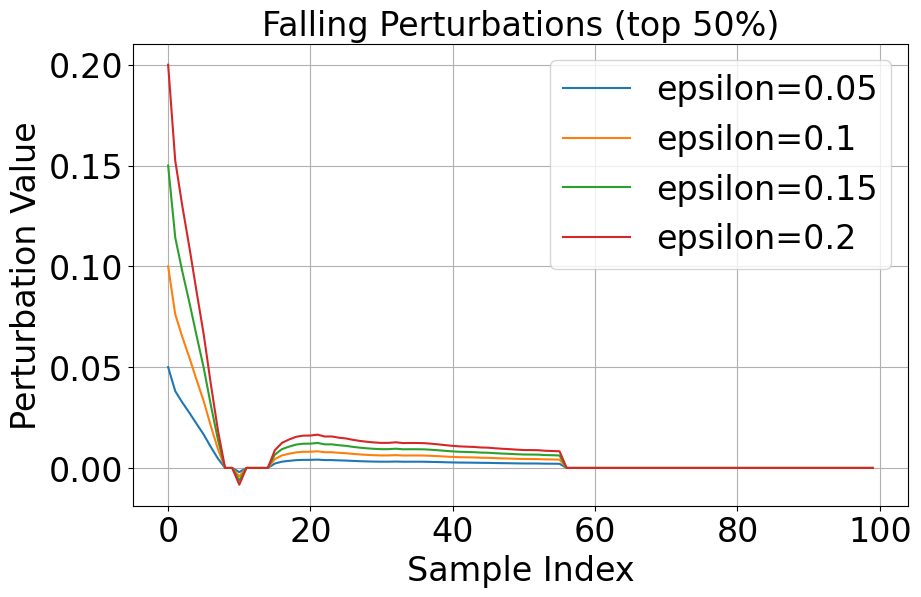

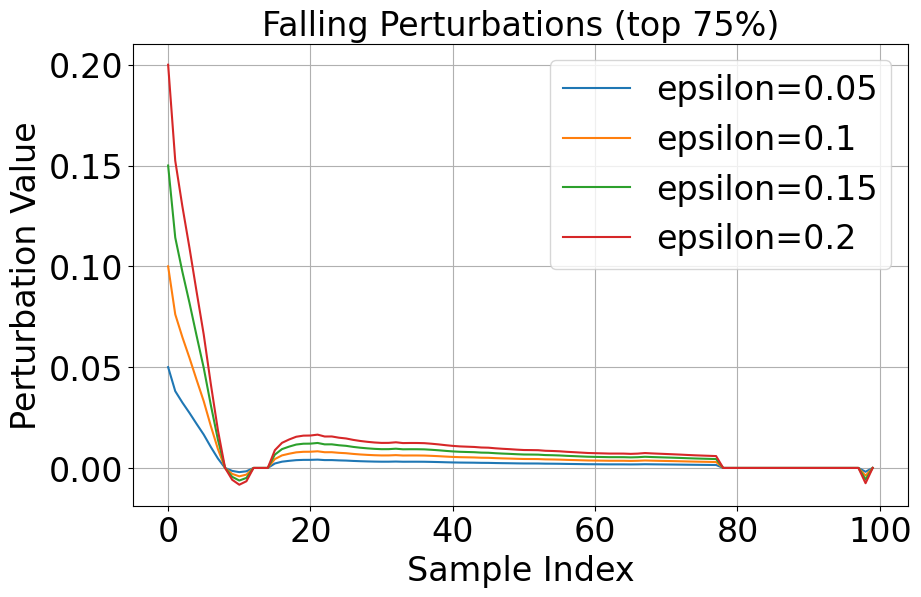

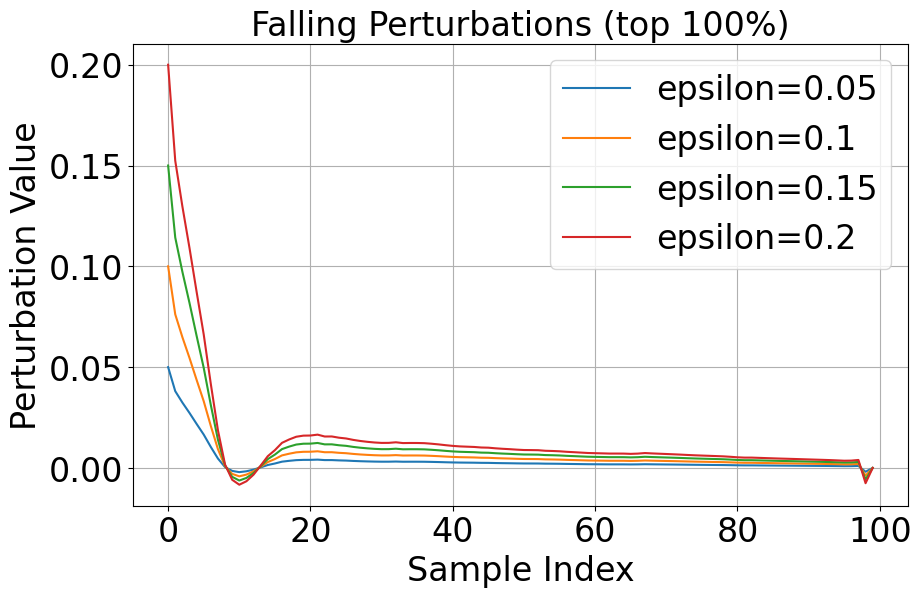

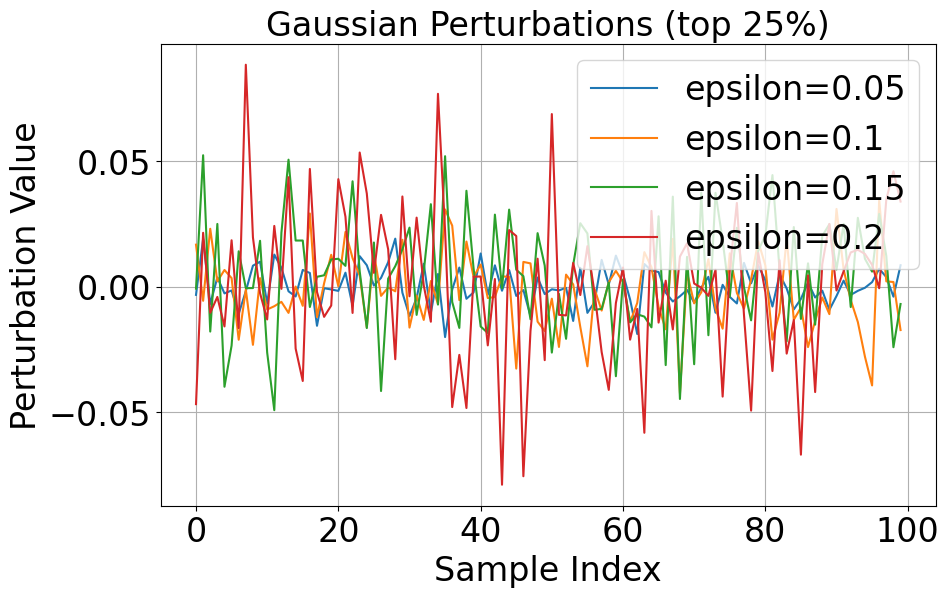

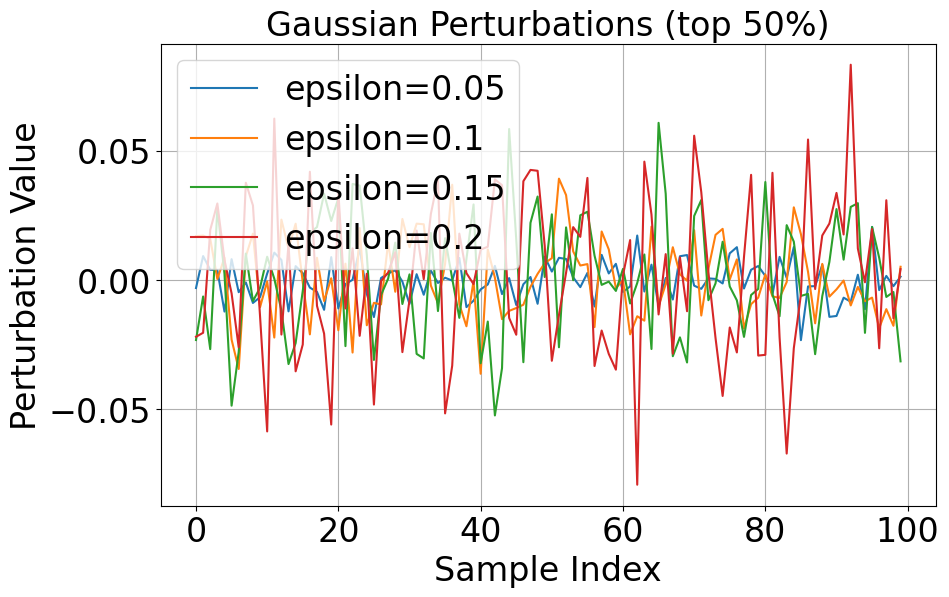

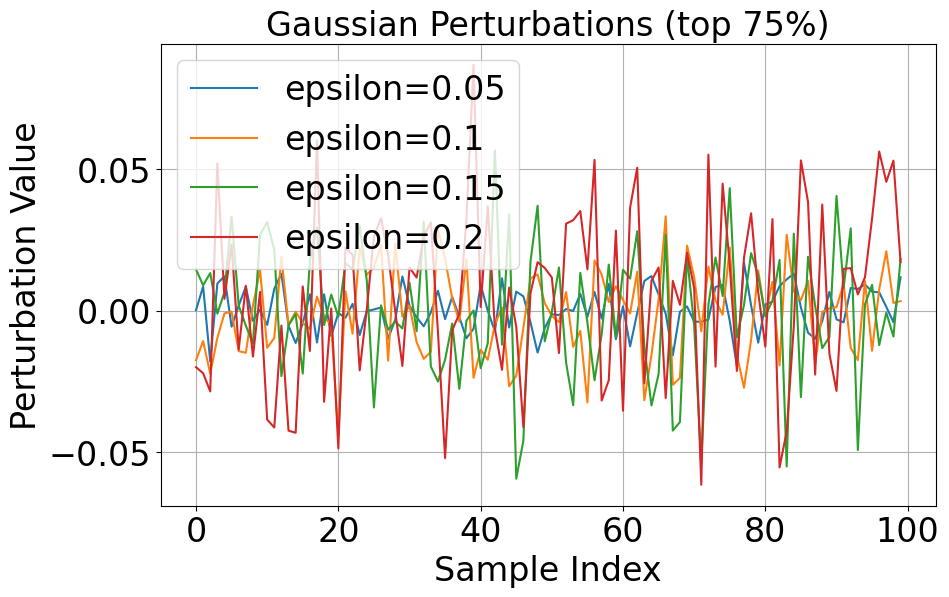

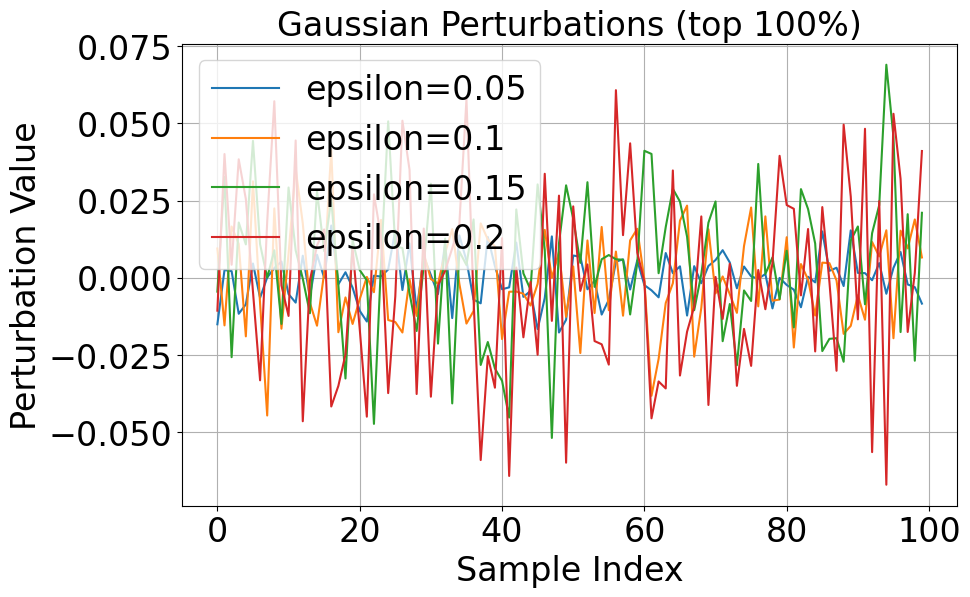

In [27]:
for top_percent in top_percentages:
    plt.figure(figsize=(10,6))
    for i, epsilon in enumerate(epsilons):
        plt.plot(all_charting_rising_deltas[top_percent][i], label=f"epsilon={epsilon}")
    plt.xlabel("Sample Index")
    plt.ylabel("Perturbation Value")
    plt.title(f"Rising Perturbations (top {top_percent}%)")
    plt.legend()
    plt.grid(True)
    plt.show()

for top_percent in top_percentages:
    plt.figure(figsize=(10,6))
    for i, epsilon in enumerate(epsilons):
        plt.plot(all_charting_falling_deltas[top_percent][i], label=f"epsilon={epsilon}")
    plt.xlabel("Sample Index")
    plt.ylabel("Perturbation Value")
    plt.title(f"Falling Perturbations (top {top_percent}%)")
    plt.legend()
    plt.grid(True)
    plt.show()

for top_percent in top_percentages:
    plt.figure(figsize=(10,6))
    for i, epsilon in enumerate(epsilons):
        plt.plot(all_gaussian_noises[top_percent][i], label=f"epsilon={epsilon}")
    plt.xlabel("Sample Index")
    plt.ylabel("Perturbation Value")
    plt.title(f"Gaussian Perturbations (top {top_percent}%)")
    plt.legend()
    plt.grid(True)
    plt.show()

In [28]:
for top_percent in top_percentages:
    print(f"\nTOP {top_percent}%")
    print(f"{'Epsilon':<10}{'Rising RMS':<15}{'Falling RMS':<15}{'Combined RMS':<15}{'Gaussian RMS':<15}")
    print("-"*70)

    rising_rms_values = []
    falling_rms_values = []
    combined_rms_values = []
    gaussian_rms_values = []

    for i, epsilon in enumerate(epsilons):
        rising_rms = np.sqrt(np.mean(all_charting_rising_deltas[top_percent][i]**2))
        falling_rms = np.sqrt(np.mean(all_charting_falling_deltas[top_percent][i]**2))
        combined_rms = np.sqrt((rising_rms**2 + falling_rms**2) / 2)
        gaussian_rms = np.sqrt(np.mean(all_gaussian_noises[top_percent][i]**2))

        rising_rms_values.append(rising_rms)
        falling_rms_values.append(falling_rms)
        combined_rms_values.append(combined_rms)
        gaussian_rms_values.append(gaussian_rms)

        print(f"{epsilon:<10.2f}{rising_rms:<15.6f}{falling_rms:<15.6f}{combined_rms:<15.6f}{gaussian_rms:<15.6f}")


TOP 25%
Epsilon   Rising RMS     Falling RMS    Combined RMS   Gaussian RMS   
----------------------------------------------------------------------
0.05      0.006678       0.008275       0.007519       0.007519       
0.10      0.013357       0.016550       0.015038       0.015038       
0.15      0.020035       0.024825       0.022558       0.022558       
0.20      0.026713       0.033100       0.030077       0.030077       

TOP 50%
Epsilon   Rising RMS     Falling RMS    Combined RMS   Gaussian RMS   
----------------------------------------------------------------------
0.05      0.006716       0.008374       0.007590       0.007590       
0.10      0.013432       0.016747       0.015180       0.015180       
0.15      0.020149       0.025121       0.022771       0.022771       
0.20      0.026865       0.033494       0.030361       0.030361       

TOP 75%
Epsilon   Rising RMS     Falling RMS    Combined RMS   Gaussian RMS   
--------------------------------------------------

Percentage = 25 and Epsilon = 0.05


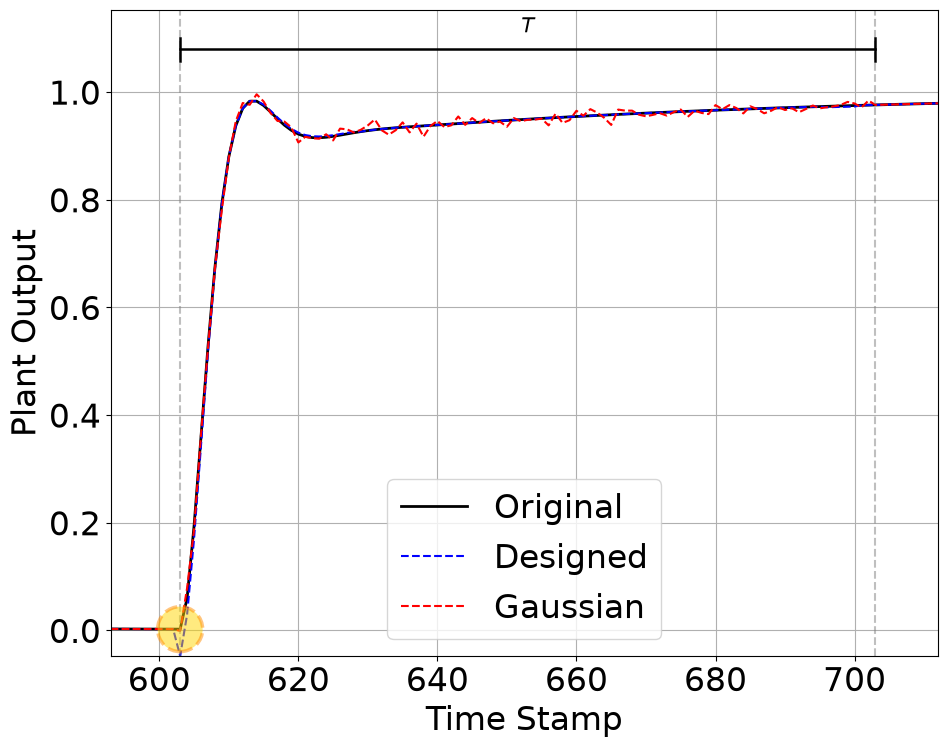

Percentage = 25 and Epsilon = 0.1


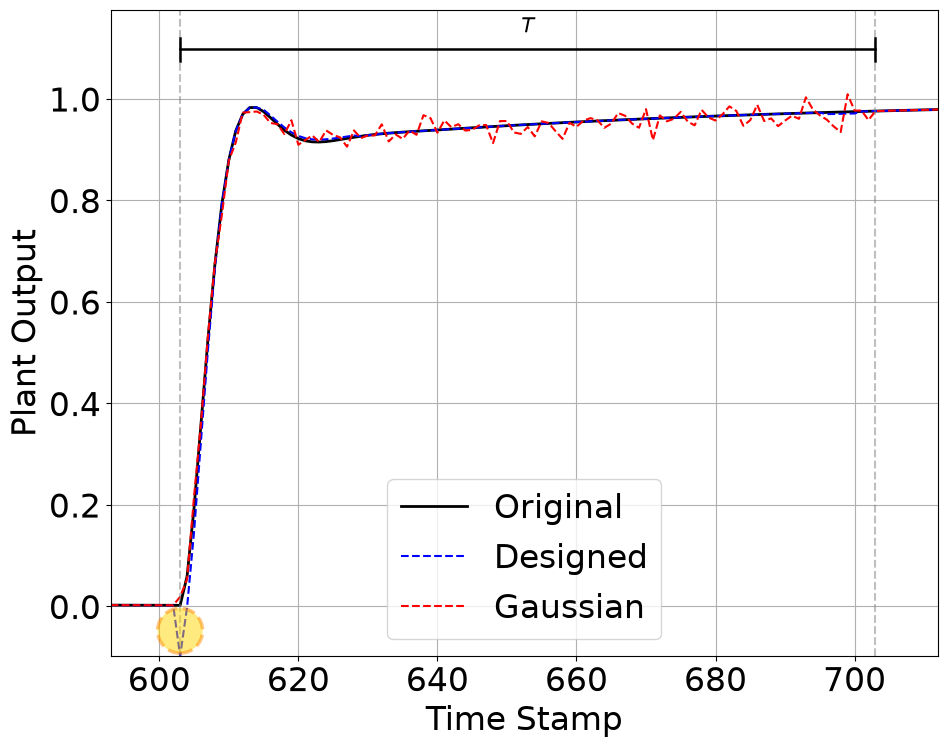

Percentage = 25 and Epsilon = 0.15


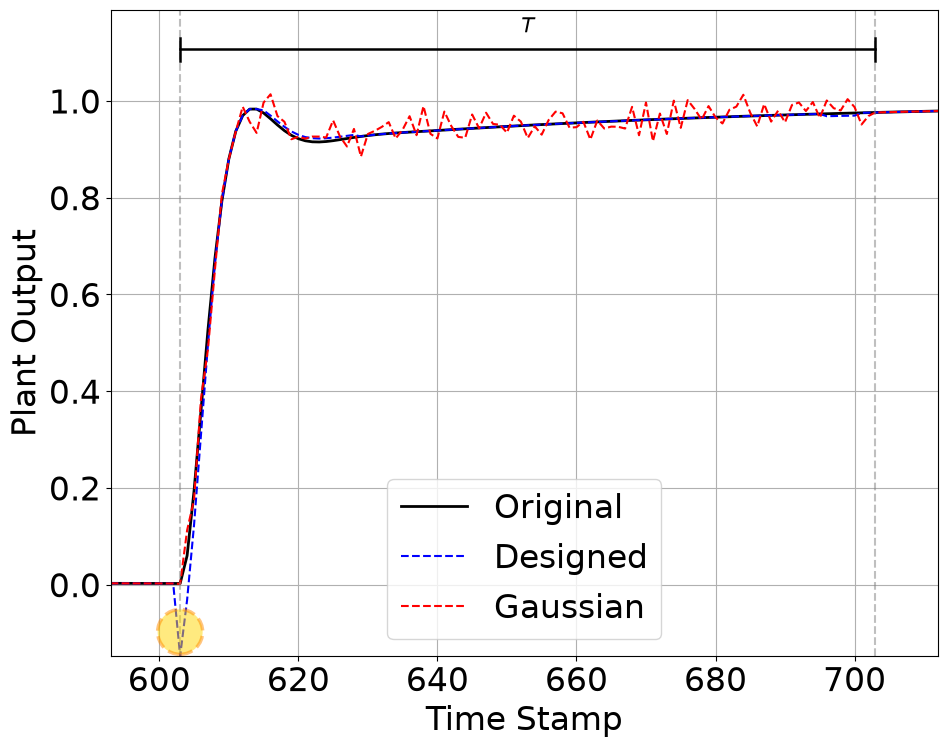

Percentage = 25 and Epsilon = 0.2


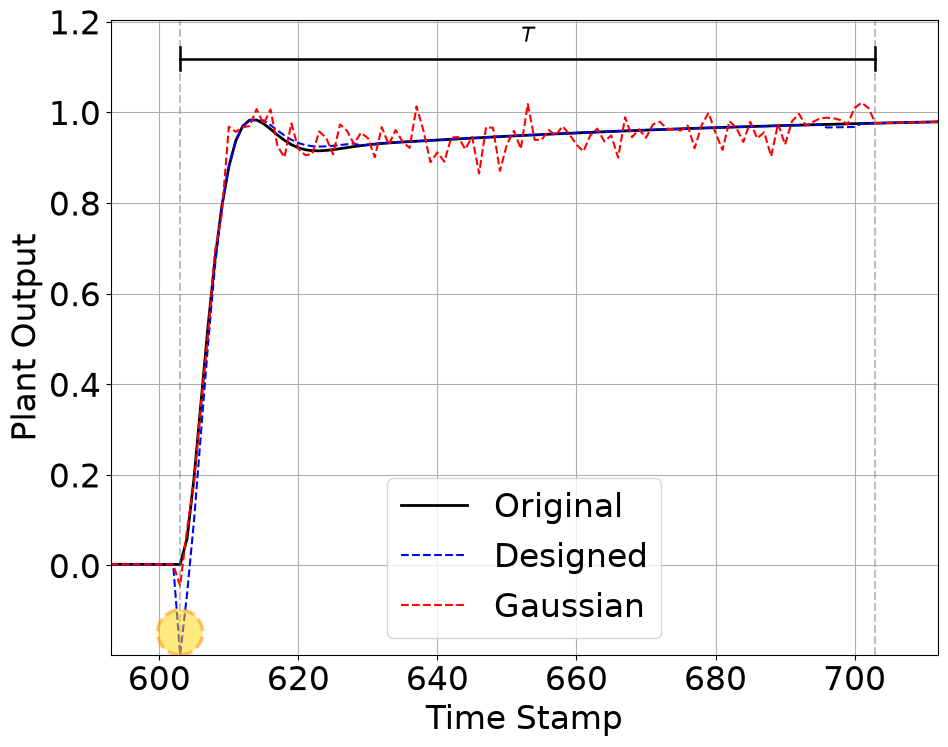

Percentage = 50 and Epsilon = 0.05


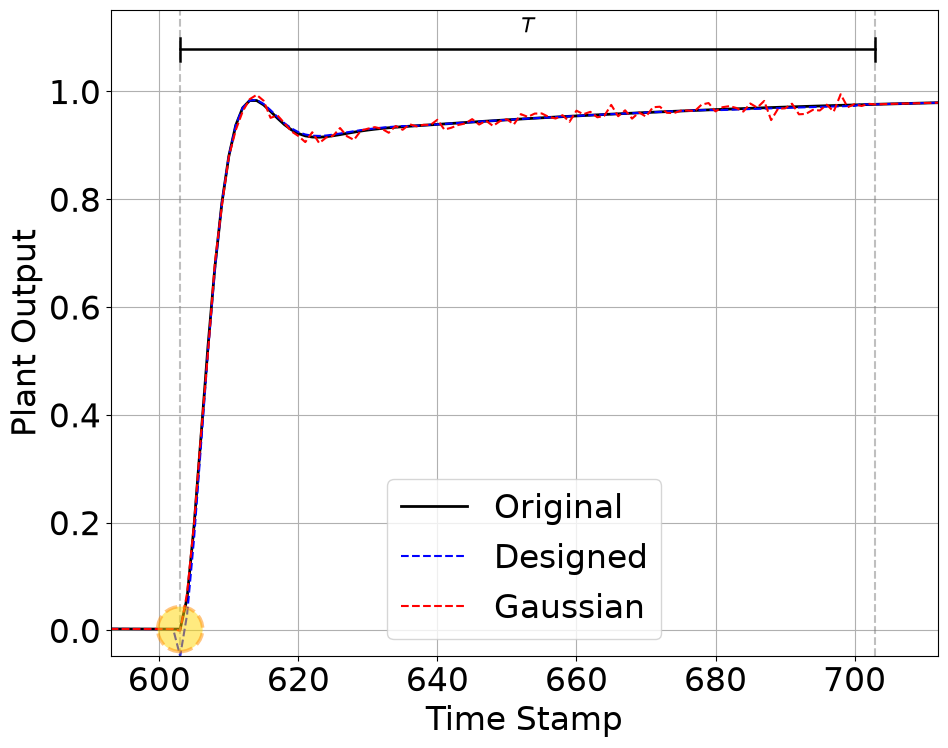

Percentage = 50 and Epsilon = 0.1


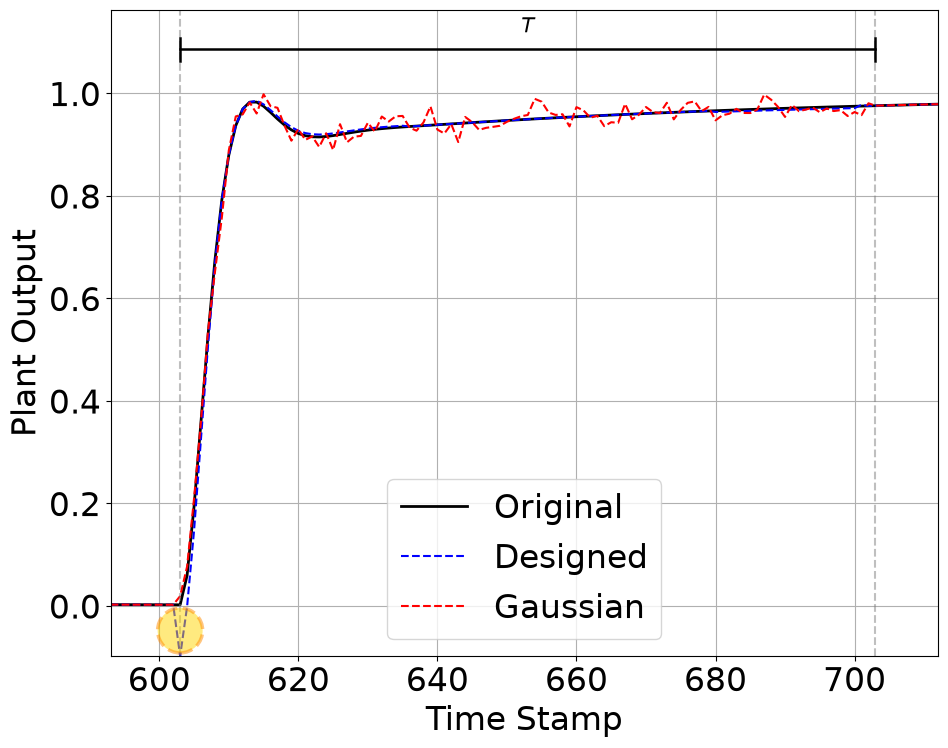

Percentage = 50 and Epsilon = 0.15


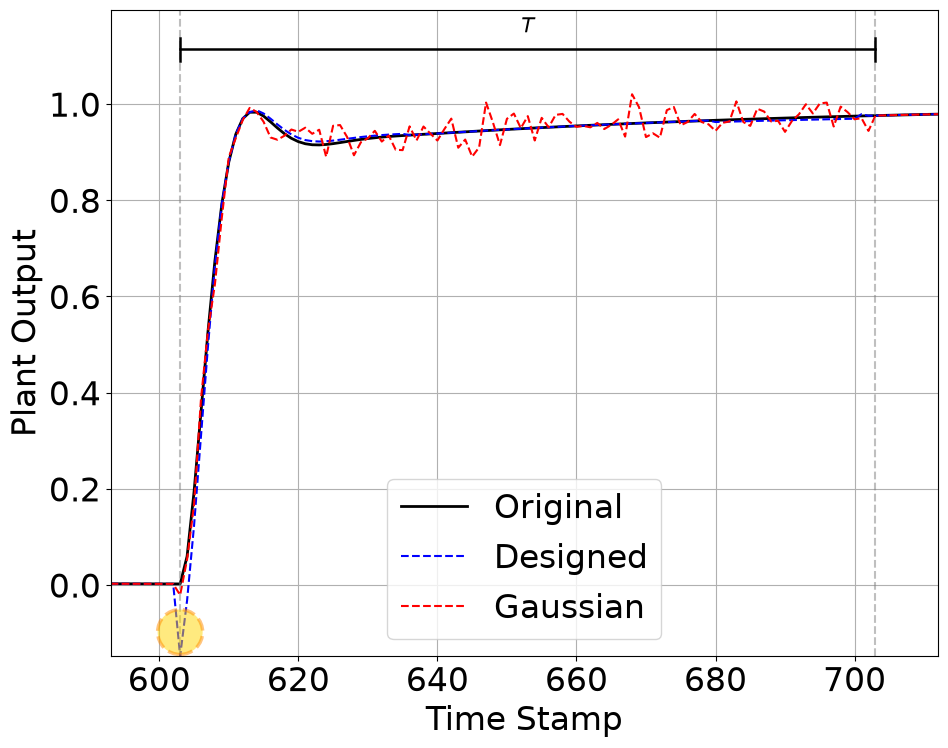

Percentage = 50 and Epsilon = 0.2


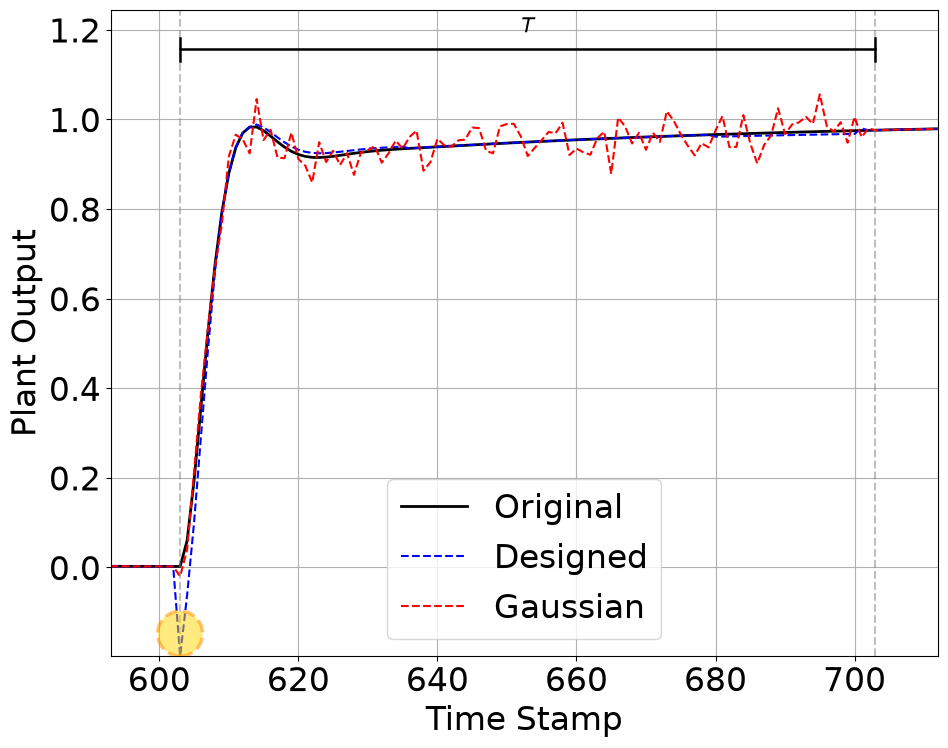

Percentage = 75 and Epsilon = 0.05


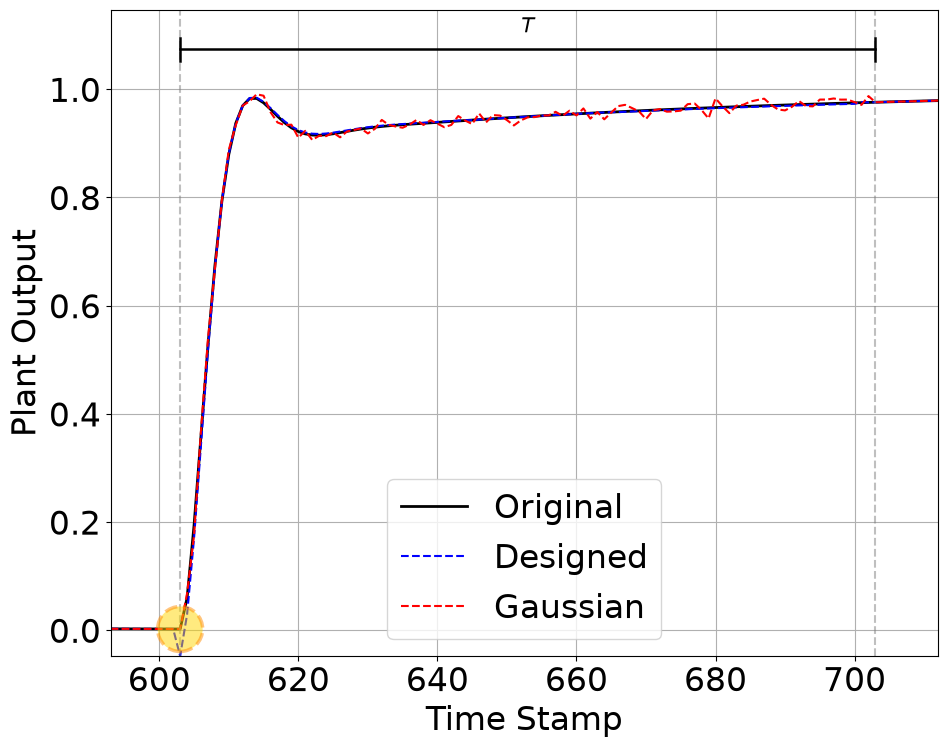

Percentage = 75 and Epsilon = 0.1


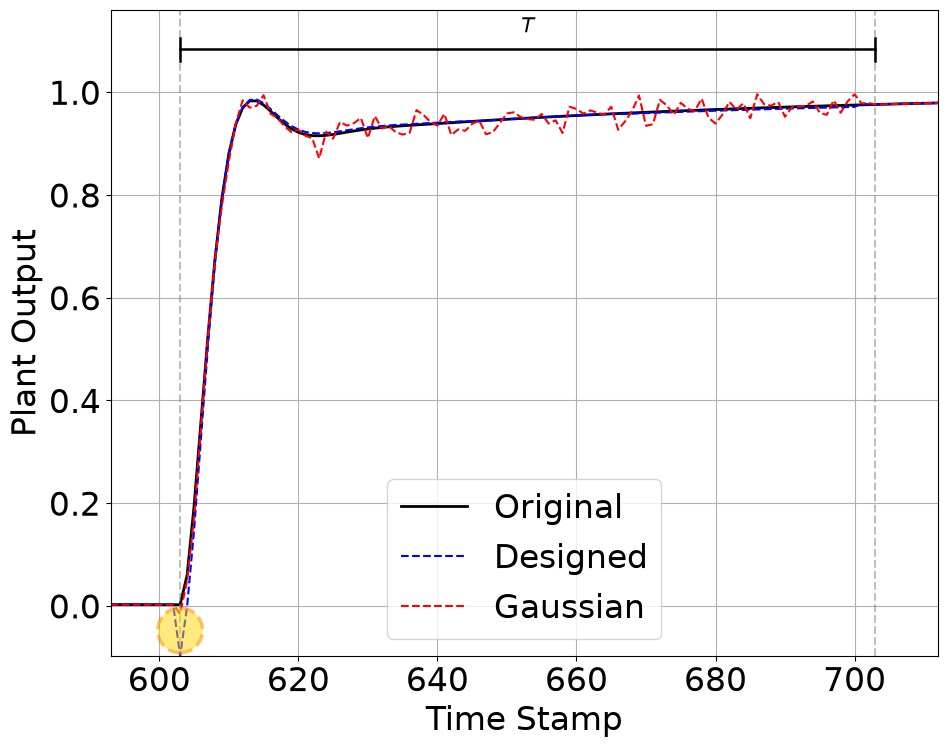

Percentage = 75 and Epsilon = 0.15


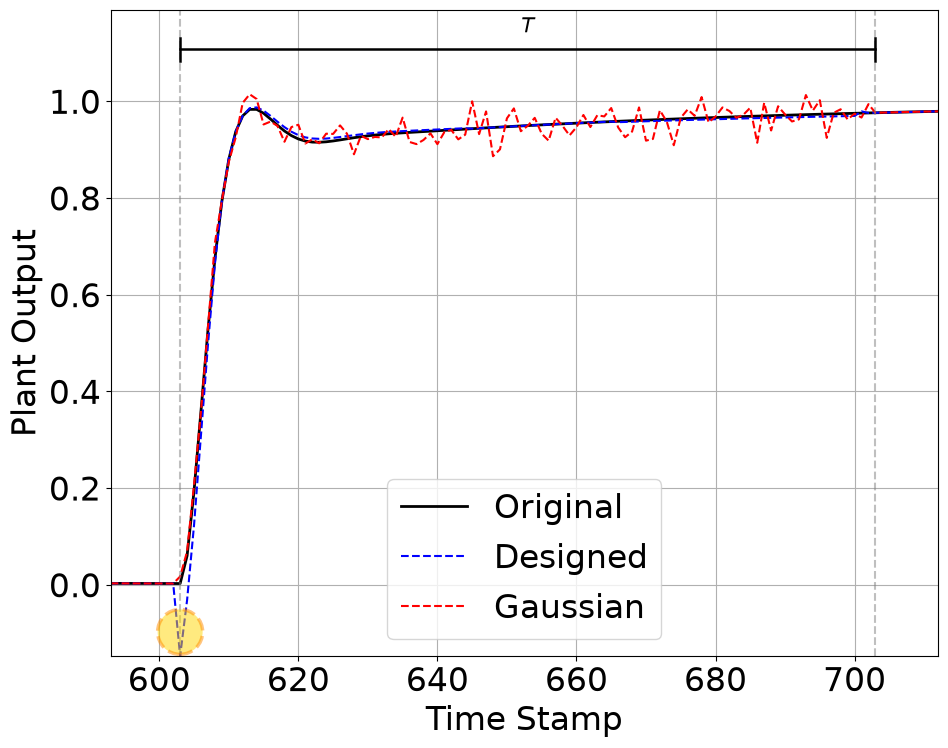

Percentage = 75 and Epsilon = 0.2


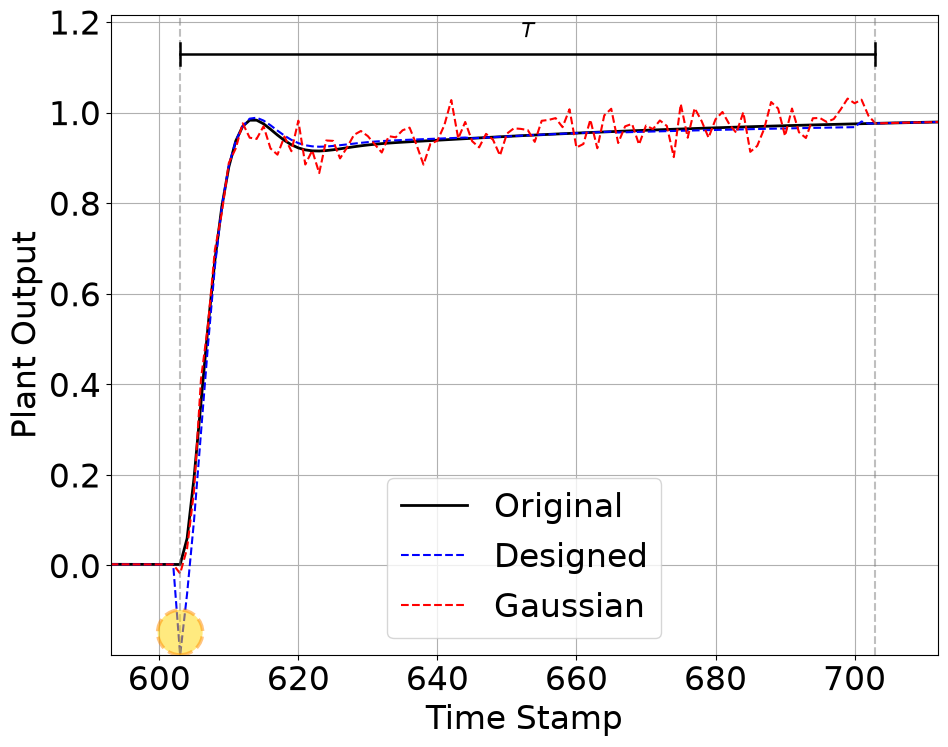

Percentage = 100 and Epsilon = 0.05


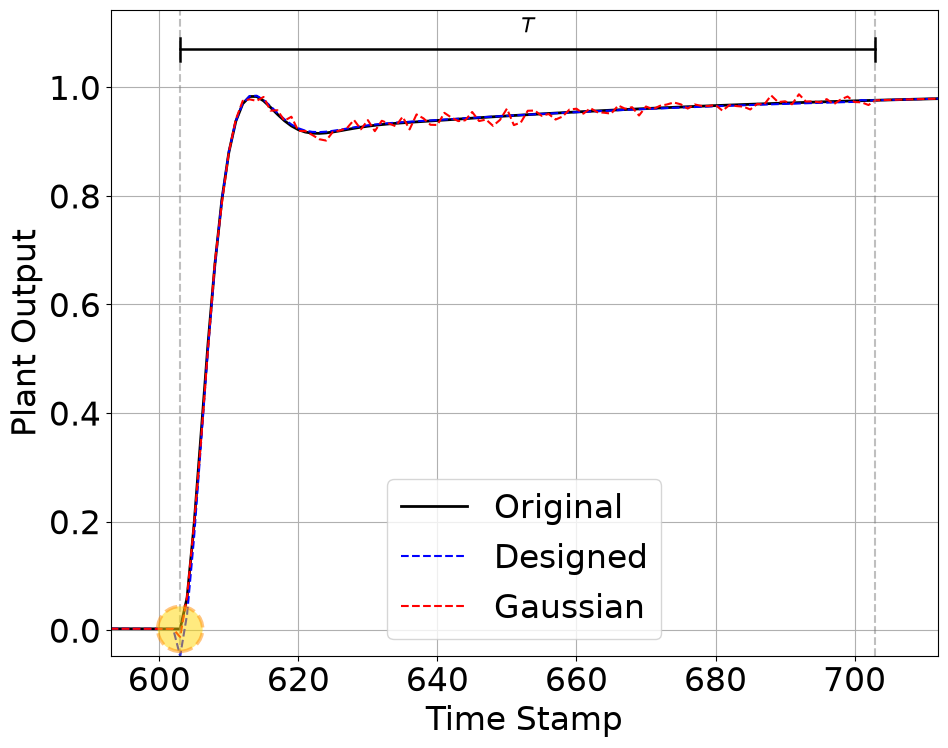

Percentage = 100 and Epsilon = 0.1


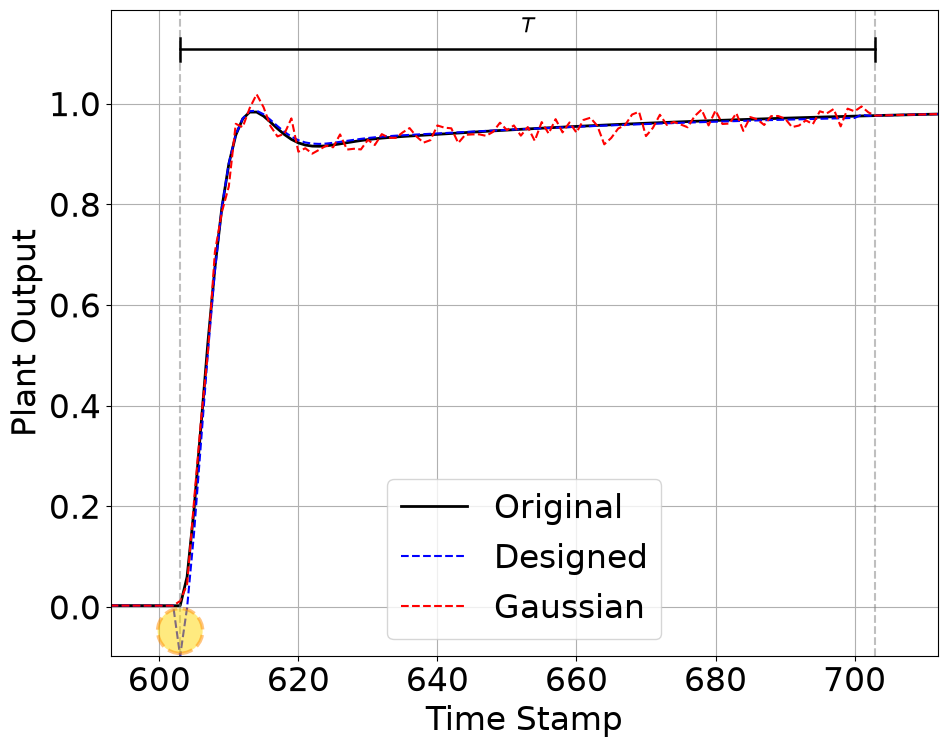

Percentage = 100 and Epsilon = 0.15


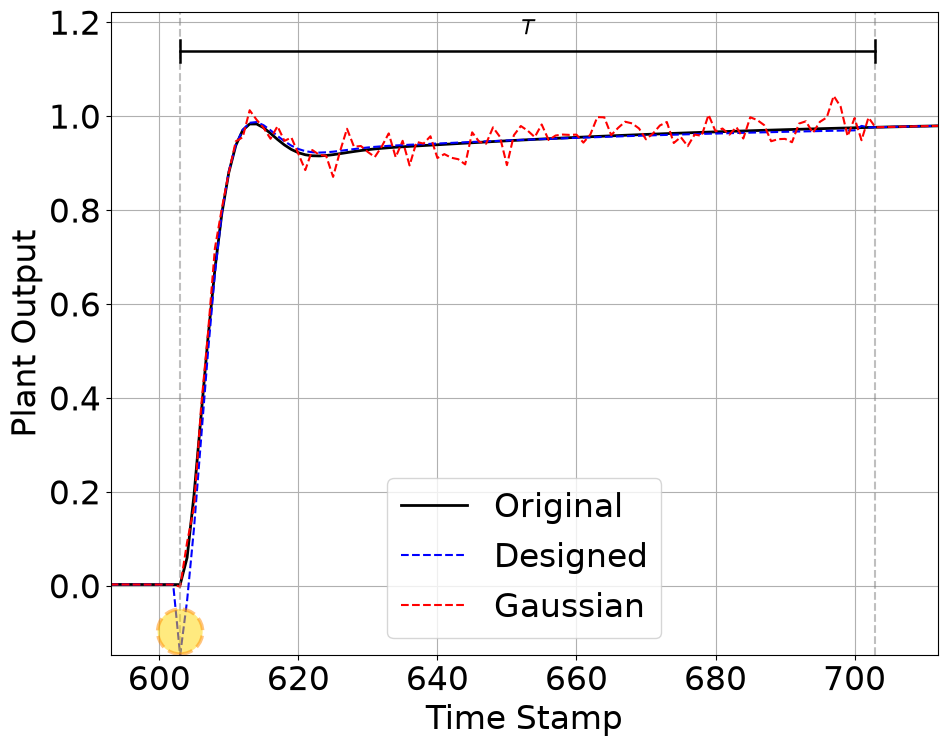

Percentage = 100 and Epsilon = 0.2


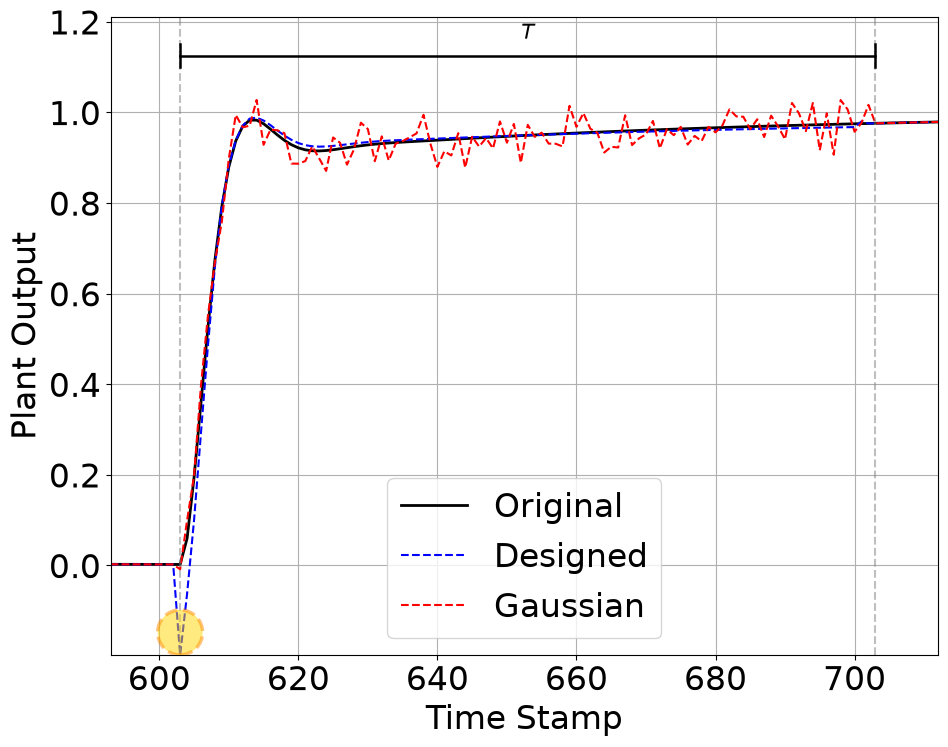

In [8]:
calculated_train_files = {}
calculated_val_files = {}
gaussian_train_files = {}
gaussian_val_files = {}

transition_start = 603
transition_length = 100
before = 10
after = 10

for top_percent in top_percentages:
    for epsilon in epsilons:
        calculated_pattern = (f"adversarialTop{top_percent}PercentDCMotorUpAndDownStepDatasets_{epsilon}/"f"adversarial_top{top_percent}_calculated_DC_sum_test_*.csv")
        calculated_files = glob.glob(calculated_pattern)
        calculated_train_files[top_percent, epsilon] = calculated_files[:7]
        calculated_val_files[top_percent, epsilon] = calculated_files[7:9]

        gaussian_pattern = (f"adversarialTop{top_percent}PercentDCMotorUpAndDownStepDatasets_{epsilon}/"f"adversarial_top{top_percent}_gaussian_DC_sum_test_*.csv")
        gaussian_files = glob.glob(gaussian_pattern)
        gaussian_train_files[top_percent, epsilon] = gaussian_files[:7]
        gaussian_val_files[top_percent, epsilon] = gaussian_files[7:9]

        original_file = step_files[0]
        calculated_file = calculated_train_files[top_percent, epsilon][0]
        gaussian_file = gaussian_train_files[top_percent, epsilon][0]

        df_original = pd.read_csv(original_file)
        df_calculated = pd.read_csv(calculated_file)
        df_gaussian = pd.read_csv(gaussian_file)

        original = df_original.iloc[:, 2].values
        calculated = df_calculated.iloc[:, 2].values
        gaussian = df_gaussian.iloc[:, 2].values

        start = max(0, transition_start - before)
        end = transition_start + transition_length + after

        x = np.arange(start, end)
        fig, ax = plt.subplots(figsize=(10, 8))

        ax.plot(x,original[start:end],linewidth=2,label="Original",color="black")
        ax.plot(x,calculated[start:end],"--",linewidth=1.5,label="Designed",color="blue")
        ax.plot(x,gaussian[start:end],"--",linewidth=1.5,label="Gaussian",color="red")

        ymin = min(original[start:end].min(),calculated[start:end].min(),gaussian[start:end].min())
        ymax = max(original[start:end].max(),calculated[start:end].max(),gaussian[start:end].max())

        yrange = ymax - ymin

        transition_begin = transition_start
        transition_end = transition_start + transition_length

        y_line = ymax + 0.08 * yrange
        tick = 0.02 * yrange

        ax.axvline(transition_begin,color="gray",linestyle="--",alpha=0.5)
        ax.axvline(transition_end,color="gray",linestyle="--",alpha=0.5)

        ax.plot([transition_begin, transition_end],[y_line, y_line],color="black",linewidth=1.8)
        ax.plot([transition_begin, transition_begin],[y_line - tick, y_line + tick],color="black",linewidth=1.8)
        ax.plot([transition_end, transition_end],[y_line - tick, y_line + tick],color="black",linewidth=1.8)
        ax.text((transition_begin + transition_end) / 2,y_line + 0.02 * yrange,r"$T$",ha="center",va="bottom",fontsize=15)

        transition_y = calculated[transition_start]
        
        ax.scatter(
            transition_start,
            calculated[transition_start]+0.05,
            s=1050,                 # size of the circle
            facecolors="gold",
            edgecolors="darkorange",
            linestyle="--",
            linewidths=2.5,
            alpha=0.5,
            zorder=5
        )
        
        ax.set_xlim(start, end - 1)
        ax.set_ylim(ymin, ymax + 0.15 * yrange)

        ax.set_xlabel("Time Stamp")
        ax.set_ylabel("Plant Output")
        ax.grid(True)
        ax.legend()

        print(f"Percentage = {top_percent} and Epsilon = {epsilon}")
        plt.tight_layout()
        plt.show()